In [16]:
print("""
=========================================================
CERN Dielectron Dataset

Notebook 5 : Feature Selection

Objectives
----------
1. Rank features using multiple feature selection techniques.
2. Compare linear and non-linear feature importance.
3. Generate a consensus feature ranking.
4. Save rankings for model training.

NOTE:
No feature is removed in this notebook.
Model Training (Notebook 6) will determine the optimal feature subset.

Author : Ivy Singh
=========================================================
""")


CERN Dielectron Dataset

Notebook 5 : Feature Selection

Objectives
----------
1. Rank features using multiple feature selection techniques.
2. Compare linear and non-linear feature importance.
3. Generate a consensus feature ranking.
4. Save rankings for model training.

NOTE:
No feature is removed in this notebook.
Model Training (Notebook 6) will determine the optimal feature subset.

Author : Ivy Singh



In [17]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection
from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_regression
)

# Models
from sklearn.ensemble import RandomForestRegressor

# Feature Importance
from sklearn.inspection import permutation_importance

# Explainability
import shap

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [18]:
# Load Engineered Dataset

df = pd.read_csv("../data/processed/dielectron_engineered.csv")

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")

print("\nDataset Shape :", df.shape)

Dataset Loaded Successfully

Dataset Shape : (99977, 31)


In [19]:
# Dataset Overview

print("="*60)

print("First Five Rows")

print("="*60)

display(df.head())

print("\n")

print("="*60)

print("Dataset Information")

print("="*60)

display(df.info())

print("\n")

print("="*60)

print("Summary Statistics")

print("="*60)

display(df.describe().T)

First Five Rows


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,Total_Energy,Energy_Difference,Energy_Ratio,Momentum1,Momentum2,Total_Momentum,Momentum_Difference,Total_PT,PT_Difference,PT_Ratio,Eta_Difference,Phi_Difference,Total_Charge,Charge_Product
0,58.7141,-7.3113,10.5310,-57.2974,12.8202,-2.2027,2.1777,1,11.2836,-1.0323,-1.8807,-11.0778,2.1454,-2.3440,-2.0728,-1,8.9484,69.9977,47.4305,5.2035,58.7141,11.2836,69.9978,47.4305,14.9656,10.6748,5.9758,0.1414,4.2505,0,-1
1,6.6119,-4.1521,-0.5799,-5.1128,4.1924,-1.0284,-3.0028,-1,17.1492,-11.7135,5.0447,11.4647,12.7536,0.8081,2.7349,1,15.8930,23.7611,10.5373,0.3856,6.6119,17.1492,23.7611,10.5373,16.9460,8.5612,0.3287,1.8365,5.7378,0,-1
2,25.5419,-11.4809,2.0417,22.7246,11.6610,1.4205,2.9656,1,15.8203,-1.4728,2.2590,-15.5888,2.6967,-2.4551,2.1486,1,38.3877,41.3622,9.7216,1.6145,25.5419,15.8203,41.3622,9.7215,14.3577,8.9643,4.3242,3.8756,0.8170,2,1
3,65.3959,7.5121,11.8871,63.8662,14.0619,2.2184,1.0072,1,25.1273,4.0879,2.5964,24.6563,4.8427,2.3302,0.5659,-1,3.7286,90.5232,40.2686,2.6026,65.3959,25.1274,90.5233,40.2685,18.9046,9.2192,2.9037,0.1118,0.4413,0,-1
4,61.4504,2.9528,-14.6227,-59.6121,14.9179,-2.0938,-1.3715,-1,13.8871,-0.2778,-2.4256,-13.6708,2.4415,-2.4237,-1.6848,-1,2.7472,75.3375,47.5633,4.4250,61.4503,13.8871,75.3374,47.5632,17.3593,12.4764,6.1103,0.3300,0.3133,-2,1




Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 99977 entries, 0 to 99976
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   E1                   99977 non-null  float64
 1   px1                  99977 non-null  float64
 2   py1                  99977 non-null  float64
 3   pz1                  99977 non-null  float64
 4   pt1                  99977 non-null  float64
 5   eta1                 99977 non-null  float64
 6   phi1                 99977 non-null  float64
 7   Q1                   99977 non-null  int64  
 8   E2                   99977 non-null  float64
 9   px2                  99977 non-null  float64
 10  py2                  99977 non-null  float64
 11  pz2                  99977 non-null  float64
 12  pt2                  99977 non-null  float64
 13  eta2                 99977 non-null  float64
 14  phi2                 99977 non-null  float64
 15  Q2                   9997

None



Summary Statistics


,count,mean,std,min,25%,50%,75%,max
E1,99977.0000,36.4360,41.2142,0.3779,8.4573,21.7171,50.0181,850.6020
px1,99977.0000,0.1364,13.4046,-250.5870,-5.2332,0.1412,5.7150,134.5390
py1,99977.0000,0.1825,13.4707,-126.0790,-5.2774,0.0989,5.6480,147.4670
pz1,99977.0000,-1.5113,51.6017,-840.9870,-15.8618,-0.3135,13.2098,760.0960
pt1,99977.0000,14.4119,12.3891,0.2196,3.7706,12.9675,20.0190,265.5780
eta1,99977.0000,-0.0642,1.4622,-4.1654,-1.2839,-0.0613,1.1444,2.6230
phi1,99977.0000,0.0216,1.7996,-3.1416,-1.5272,0.0344,1.5623,3.1414
Q1,99977.0000,-0.0055,1.0000,-1.0000,-1.0000,-1.0000,1.0000,1.0000
E2,99977.0000,44.0050,46.7528,0.4725,11.0572,25.2652,66.9268,948.3750
px2,99977.0000,-0.0034,13.1280,-233.7300,-4.7946,-0.0350,4.8201,227.3300


In [20]:
# Separate Features and Target

# Predictor Variables
X = df.drop(columns=["M"])

# Target Variable
y = df["M"]

# Sample for fast training during feature selection (10k events)
X_sample_rf = X.sample(n=10000, random_state=42)
y_sample_rf = y.loc[X_sample_rf.index]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)
print("Sampled Matrix Shape :", X_sample_rf.shape)


Feature Matrix Shape : (99977, 30)
Target Shape : (99977,)

Total Features : 30


In [21]:
# Feature Importance using Correlation
# Measures linear relationship between each feature
# and the target variable (Invariant Mass).
# Range:
# -1  -> Strong Negative Correlation
#  0  -> No Correlation
# +1  -> Strong Positive Correlation

correlation_scores = (
    df.corr(numeric_only=True)["M"]
      .drop("M")
      .abs()
      .sort_values(ascending=False)
)

correlation_df = pd.DataFrame({
    "Feature": correlation_scores.index,
    "Correlation": correlation_scores.values
})

display(correlation_df)

,Feature,Correlation
0,Total_PT,0.6283
1,Eta_Difference,0.5306
2,Total_Momentum,0.4697
3,Total_Energy,0.4697
4,pt1,0.4373
5,pt2,0.4372
6,Momentum2,0.3248
7,E2,0.3248
8,Momentum1,0.2854
9,E1,0.2854


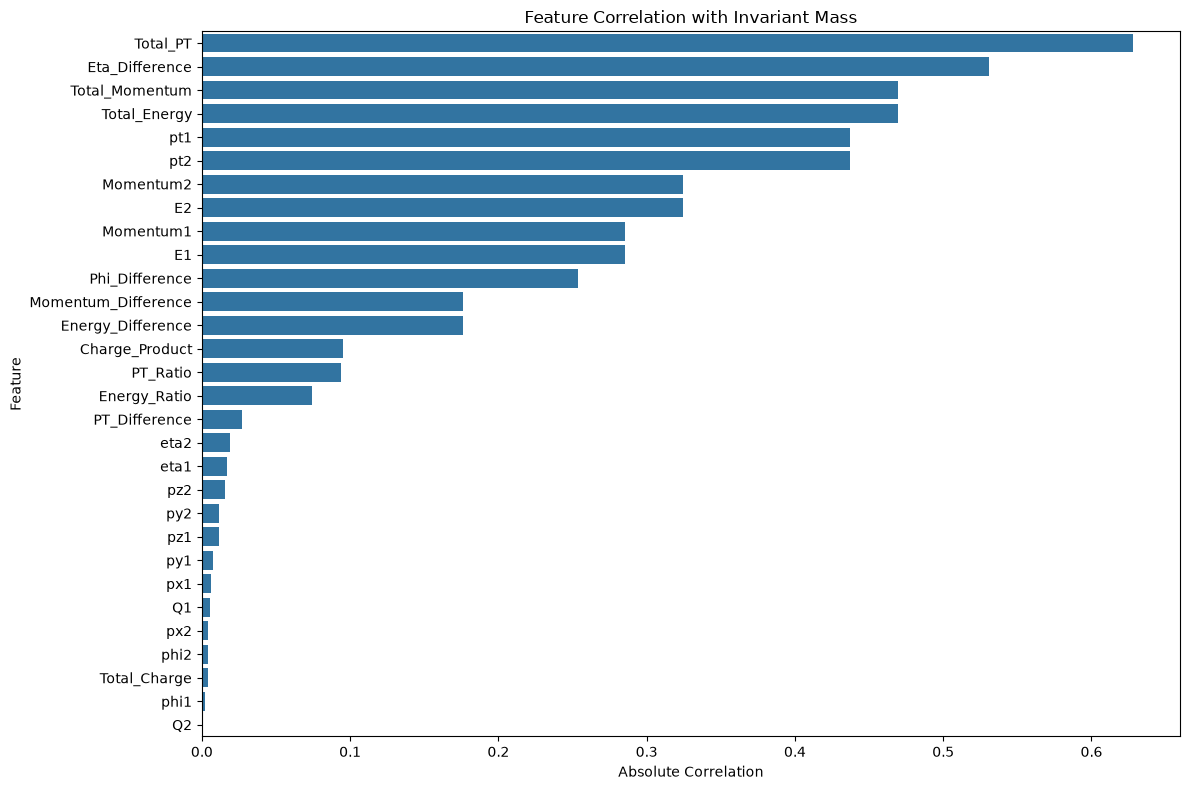

In [22]:
# Visualize Correlation Scores

plt.figure(figsize=(12,8))

sns.barplot(
    data=correlation_df,
    y="Feature",
    x="Correlation"
)

plt.title("Feature Correlation with Invariant Mass")

plt.xlabel("Absolute Correlation")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [23]:
# Feature Variance Analysis
# Features with extremely low variance generally
# contribute little information to the model.
# NOTE:
# We DO NOT remove any feature here.
# We simply record the variance.

variance = X.var()

variance = variance.sort_values(ascending=False)

variance_df = pd.DataFrame({

    "Feature": variance.index,

    "Variance": variance.values

})

display(variance_df)

,Feature,Variance
0,pz2,3773.9545
1,Total_Energy,3291.3562
2,Total_Momentum,3291.3561
3,pz1,2662.7319
4,Momentum2,2185.8202
5,E2,2185.8201
6,Momentum_Difference,2084.5062
7,Energy_Difference,2084.5062
8,E1,1698.6104
9,Momentum1,1698.6104


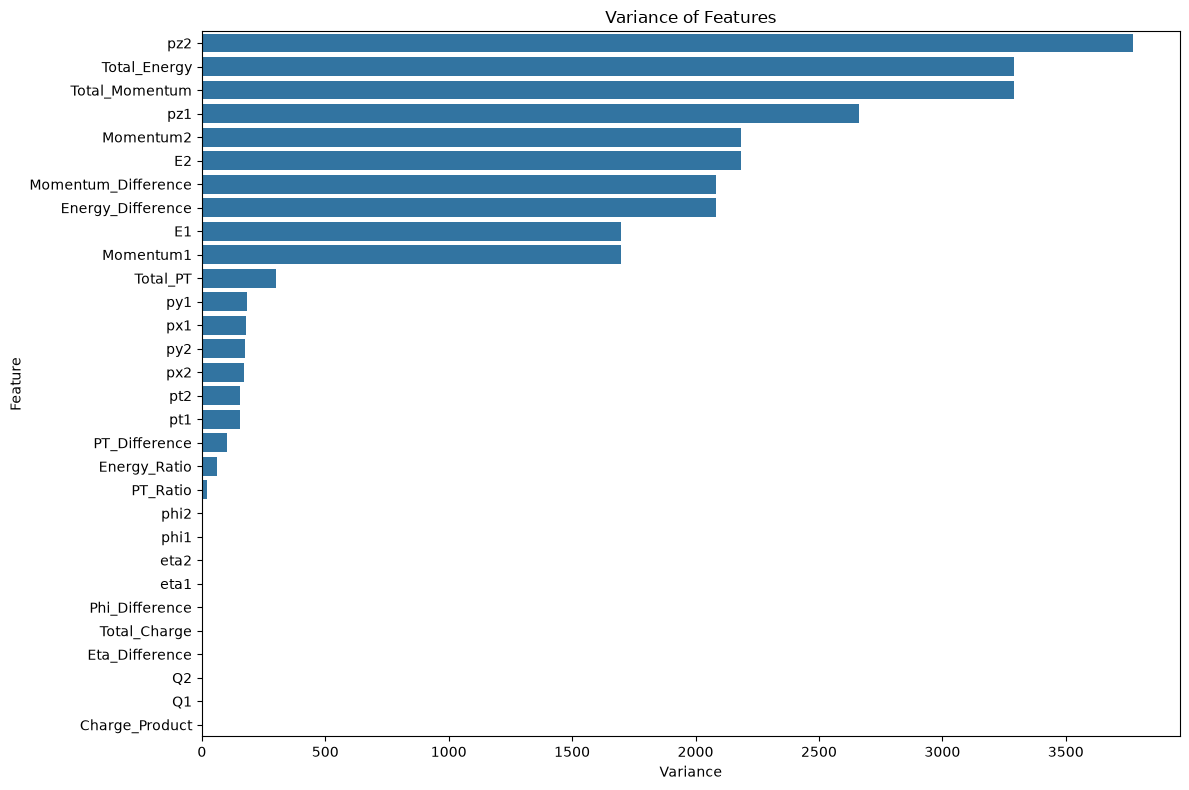

In [24]:
# Visualize Feature Variance

plt.figure(figsize=(12,8))

sns.barplot(
    data=variance_df,
    y="Feature",
    x="Variance"
)

plt.title("Variance of Features")

plt.xlabel("Variance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [25]:
# Mutual Information Analysis
# Mutual Information is computed on a 10,000 sample for speed.

mi_scores = mutual_info_regression(
    X_sample_rf,
    y_sample_rf,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi_scores
})

mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
)

display(mi_df)


,Feature,Mutual Information
26,Eta_Difference,0.3836
21,Total_Momentum,0.3278
16,Total_Energy,0.3278
23,Total_PT,0.2785
27,Phi_Difference,0.2581
12,pt2,0.1514
4,pt1,0.1408
19,Momentum1,0.1072
0,E1,0.1072
20,Momentum2,0.1057


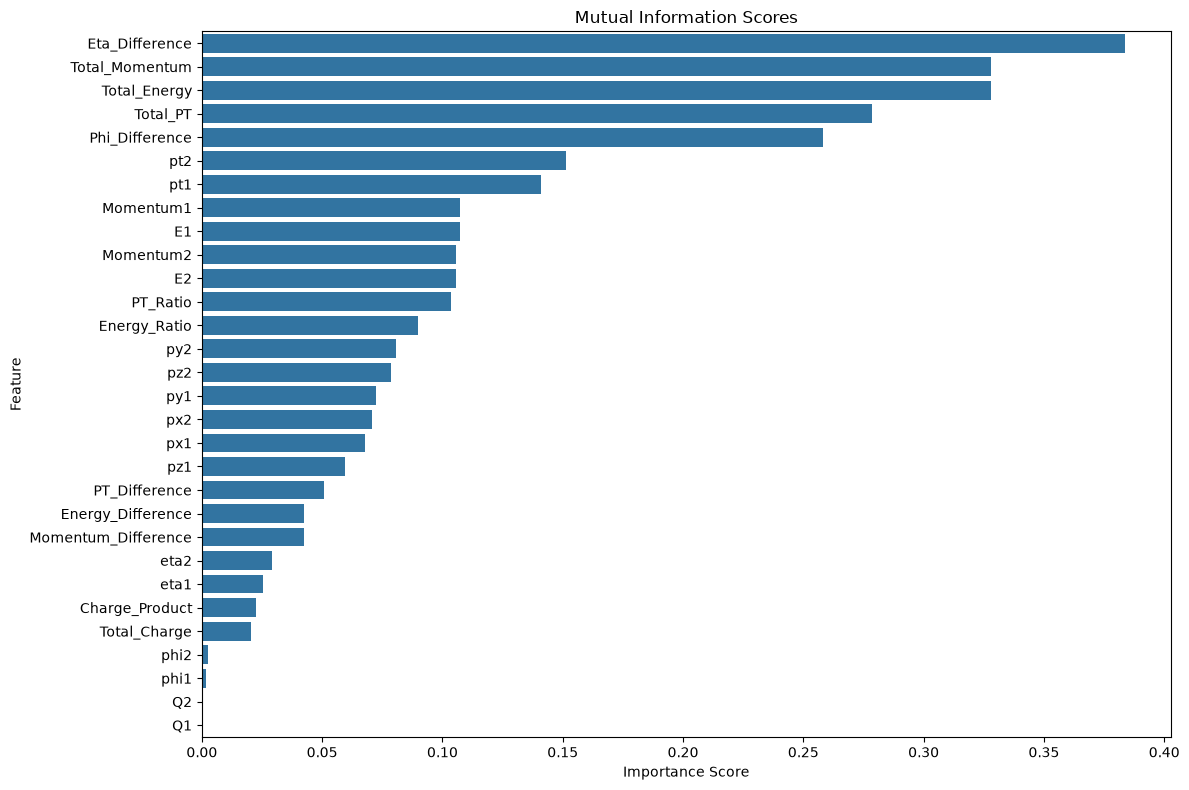

In [26]:
# Visualize Mutual Information Scores

plt.figure(figsize=(12,8))

sns.barplot(
    data=mi_df,
    y="Feature",
    x="Mutual Information"
)

plt.title("Mutual Information Scores")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [27]:
# Random Forest Feature Importance
# Fitted on a 10,000 row sample with 100 trees to be fast.

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_sample_rf, y_sample_rf)

rf_df = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest": rf.feature_importances_
})

rf_df = rf_df.sort_values(
    by="Random Forest",
    ascending=False
)

display(rf_df)


,Feature,Random Forest
23,Total_PT,0.3787
26,Eta_Difference,0.3540
24,PT_Difference,0.0476
27,Phi_Difference,0.0467
21,Total_Momentum,0.0406
16,Total_Energy,0.0391
0,E1,0.0259
19,Momentum1,0.0256
20,Momentum2,0.0156
8,E2,0.0153


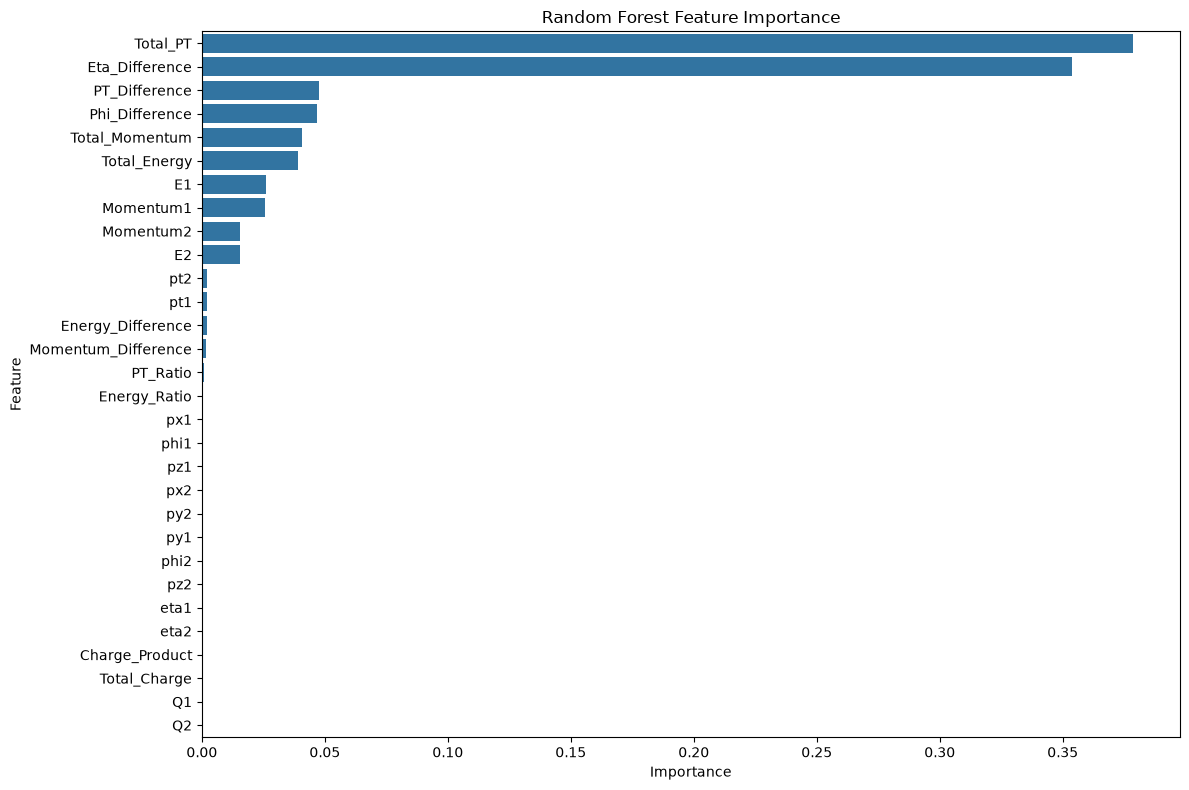

In [28]:
# Visualize Random Forest Feature Importance

plt.figure(figsize=(12,8))

sns.barplot(
    data=rf_df,
    y="Feature",
    x="Random Forest"
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [29]:
# Permutation Importance
# Shuffling features is run on the sample and in parallel.

perm = permutation_importance(
    rf,
    X_sample_rf,
    y_sample_rf,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Permutation",
    ascending=False
)

display(perm_df)


,Feature,Permutation
23,Total_PT,0.8848
26,Eta_Difference,0.8219
27,Phi_Difference,0.1097
21,Total_Momentum,0.0689
24,PT_Difference,0.0678
16,Total_Energy,0.0662
19,Momentum1,0.0378
0,E1,0.0369
20,Momentum2,0.0232
8,E2,0.0224


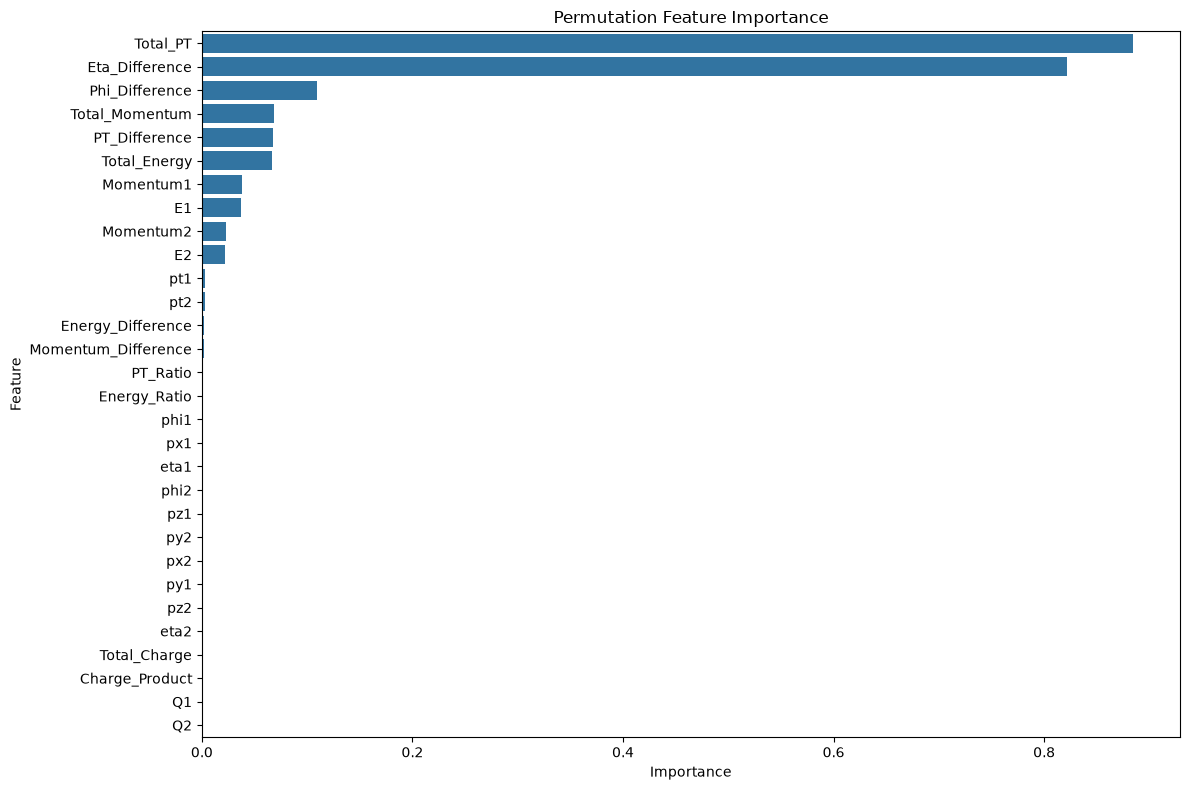

In [30]:
# Visualize Permutation Importance

plt.figure(figsize=(12,8))

sns.barplot(

    data=perm_df,

    y="Feature",

    x="Permutation"

)

plt.title("Permutation Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [31]:
# SHAP Explainability
# SHAP (SHapley Additive exPlanations) explains
# how much each feature contributes to the prediction
# made by the trained Random Forest model.
# Since the complete dataset contains 100,000
# dielectron events, computing SHAP values for every
# event is computationally expensive.
# Therefore, a representative random sample of
# 1,000 events is used to obtain reliable feature
# explanations while significantly reducing
# computation time.

# Randomly sample 200 events from the dataset
X_sample = X.sample(
    n=200,
    random_state=42
)

# Create a SHAP TreeExplainer for the trained
# Random Forest model
explainer = shap.TreeExplainer(rf)

# Compute SHAP values for the sampled events
shap_values = explainer.shap_values(X_sample)

print("SHAP Values Computed Successfully")

SHAP Values Computed Successfully


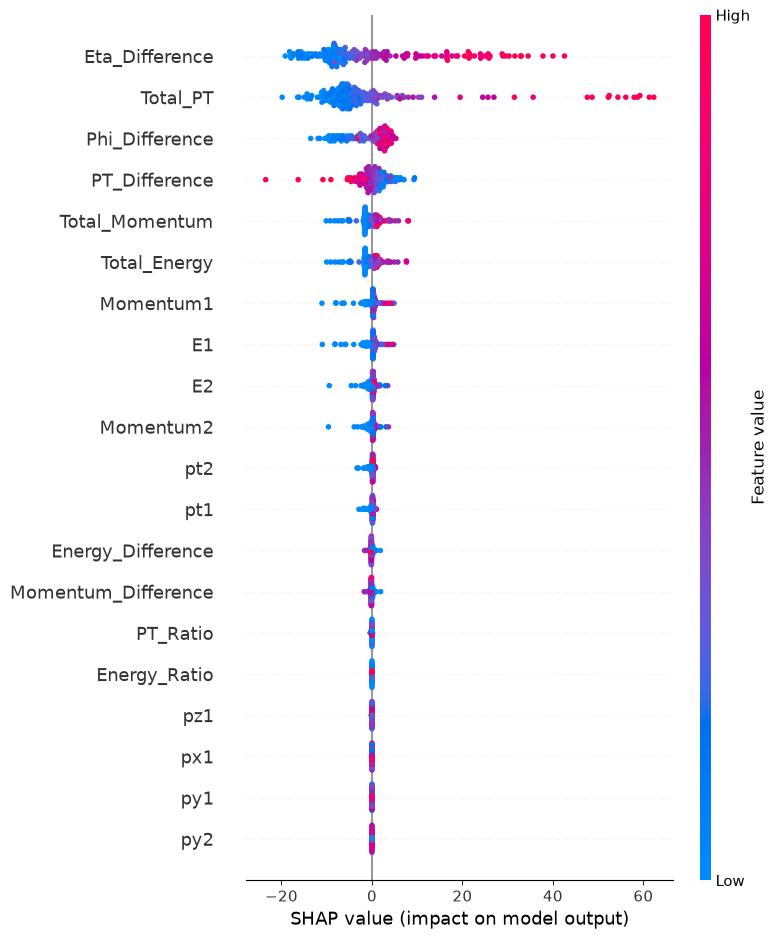

In [32]:
# SHAP Summary Plot
# Displays the contribution of every feature
# across all sampled events.
# • Feature importance
# • Direction of impact
# • Distribution of SHAP values

shap.summary_plot(
    shap_values,
    X_sample
)

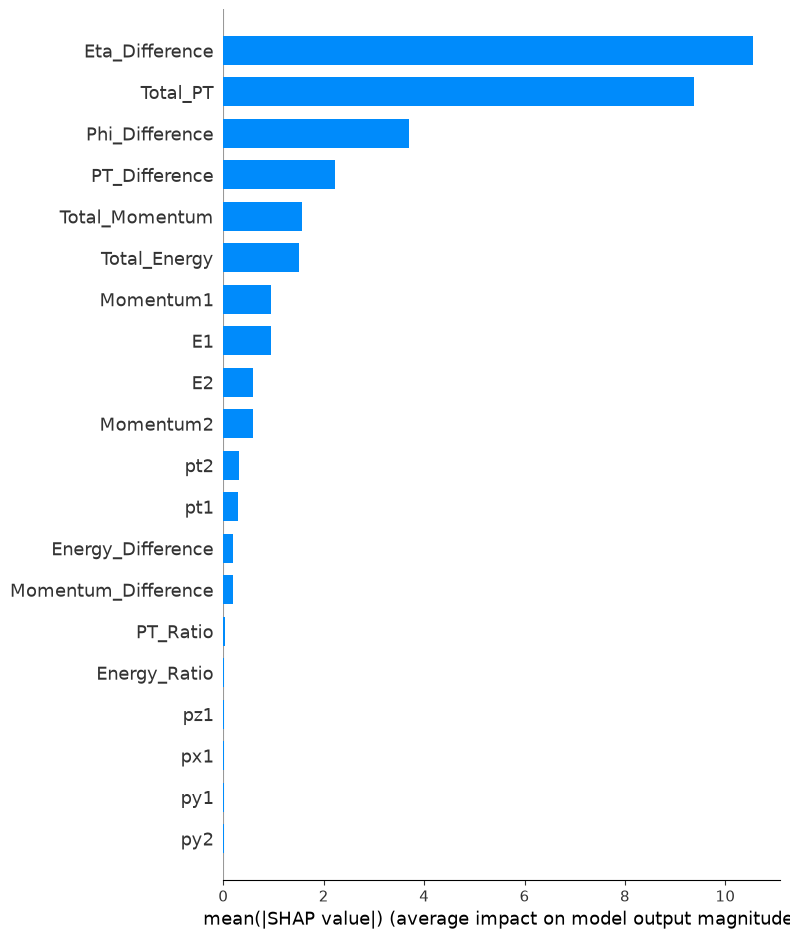

In [33]:
# SHAP Feature Importance (Bar Plot)
# Displays the mean absolute SHAP value for
# every feature.
# Larger SHAP value
# Greater contribution towards model prediction.

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [34]:
# Normalize Feature Importance Scores
# Each feature selection technique produces scores
# on a different numerical scale.
# To compare them fairly, Min-Max normalization
# is applied so that every score lies between
# 0 and 1.
# Formula:
# Normalized Score =
# (x - min) / (max - min)
# This ensures that no single feature selection
# technique dominates the final ranking simply
# because of its numerical scale.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Create DataFrame for normalized scores
normalized_scores = pd.DataFrame(index=X.columns)

# Normalize Correlation Scores
normalized_scores["Correlation"] = scaler.fit_transform(
    correlation_df.set_index("Feature")
                  .loc[X.columns]
                  .values
).flatten()

# Normalize Variance Scores
normalized_scores["Variance"] = scaler.fit_transform(
    variance_df.set_index("Feature")
               .loc[X.columns]
               .values
).flatten()

# Normalize Mutual Information Scores
normalized_scores["Mutual Information"] = scaler.fit_transform(
    mi_df.set_index("Feature")
         .loc[X.columns]
         .values
).flatten()

# Normalize Random Forest Scores
normalized_scores["Random Forest"] = scaler.fit_transform(
    rf_df.set_index("Feature")
         .loc[X.columns]
         .values
).flatten()

# Normalize Permutation Scores
normalized_scores["Permutation"] = scaler.fit_transform(
    perm_df.set_index("Feature")
           .loc[X.columns]
           .values
).flatten()

# Compute mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "SHAP": shap_importance
})

# Normalize SHAP Scores
normalized_scores["SHAP"] = scaler.fit_transform(
    shap_df.set_index("Feature")
           .loc[X.columns]
           .values
).flatten()

display(normalized_scores.head())

,Correlation,Variance,Mutual Information,Random Forest,Permutation,SHAP
E1,0.4539,0.4499,0.2796,0.0683,0.0417,0.0895
px1,0.0091,0.0474,0.1773,0.0004,0.0001,0.0007
py1,0.0116,0.0478,0.1885,0.0004,0.0001,0.0005
pz1,0.0180,0.7055,0.1549,0.0004,0.0001,0.0008
pt1,0.6958,0.0404,0.3670,0.0055,0.0038,0.0279


In [35]:
# Consensus Feature Score
# Instead of relying on a single feature selection
# technique, we combine evidence from multiple
# methods.
# Equal weights are assigned to each normalized
# importance score.
# This provides a more robust estimate of the
# overall usefulness of every feature.

normalized_scores["Consensus Score"] = normalized_scores.mean(axis=1)

feature_rankings = (
    normalized_scores
    .sort_values(
        by="Consensus Score",
        ascending=False
    )
)

display(feature_rankings)

,Correlation,Variance,Mutual Information,Random Forest,Permutation,SHAP,Consensus Score
Eta_Difference,0.8444,0.0002,1.0000,0.9345,0.9289,1.0000,0.7847
Total_PT,1.0000,0.0790,0.7260,1.0000,1.0000,0.8885,0.7822
Total_Momentum,0.7475,0.8721,0.8546,0.1073,0.0779,0.1485,0.4680
Total_Energy,0.7475,0.8721,0.8546,0.1033,0.0748,0.1434,0.4659
Phi_Difference,0.4033,0.0002,0.6728,0.1232,0.1240,0.3505,0.2790
Momentum2,0.5167,0.5791,0.2755,0.0411,0.0262,0.0556,0.2490
E2,0.5167,0.5791,0.2755,0.0404,0.0253,0.0561,0.2488
Momentum1,0.4539,0.4499,0.2796,0.0674,0.0427,0.0905,0.2307
E1,0.4539,0.4499,0.2796,0.0683,0.0417,0.0895,0.2305
pz2,0.0243,1.0000,0.2048,0.0004,0.0001,0.0005,0.2050


In [36]:
# Final Feature Ranking
# Rank features according to the Consensus Score.
# Higher Consensus Score
# More important feature.

feature_rankings["Rank"] = range(
    1,
    len(feature_rankings) + 1
)

feature_rankings = feature_rankings[
    ["Rank"] + list(feature_rankings.columns[:-1])
]

display(feature_rankings)

,Rank,Correlation,Variance,Mutual Information,Random Forest,Permutation,SHAP,Consensus Score
Eta_Difference,1,0.8444,0.0002,1.0000,0.9345,0.9289,1.0000,0.7847
Total_PT,2,1.0000,0.0790,0.7260,1.0000,1.0000,0.8885,0.7822
Total_Momentum,3,0.7475,0.8721,0.8546,0.1073,0.0779,0.1485,0.4680
Total_Energy,4,0.7475,0.8721,0.8546,0.1033,0.0748,0.1434,0.4659
Phi_Difference,5,0.4033,0.0002,0.6728,0.1232,0.1240,0.3505,0.2790
Momentum2,6,0.5167,0.5791,0.2755,0.0411,0.0262,0.0556,0.2490
E2,7,0.5167,0.5791,0.2755,0.0404,0.0253,0.0561,0.2488
Momentum1,8,0.4539,0.4499,0.2796,0.0674,0.0427,0.0905,0.2307
E1,9,0.4539,0.4499,0.2796,0.0683,0.0417,0.0895,0.2305
pz2,10,0.0243,1.0000,0.2048,0.0004,0.0001,0.0005,0.2050


In [37]:
# Top 15 Most Important Features

top_features = feature_rankings.head(15)

display(top_features)

,Rank,Correlation,Variance,Mutual Information,Random Forest,Permutation,SHAP,Consensus Score
Eta_Difference,1,0.8444,0.0002,1.0000,0.9345,0.9289,1.0000,0.7847
Total_PT,2,1.0000,0.0790,0.7260,1.0000,1.0000,0.8885,0.7822
Total_Momentum,3,0.7475,0.8721,0.8546,0.1073,0.0779,0.1485,0.4680
Total_Energy,4,0.7475,0.8721,0.8546,0.1033,0.0748,0.1434,0.4659
Phi_Difference,5,0.4033,0.0002,0.6728,0.1232,0.1240,0.3505,0.2790
Momentum2,6,0.5167,0.5791,0.2755,0.0411,0.0262,0.0556,0.2490
E2,7,0.5167,0.5791,0.2755,0.0404,0.0253,0.0561,0.2488
Momentum1,8,0.4539,0.4499,0.2796,0.0674,0.0427,0.0905,0.2307
E1,9,0.4539,0.4499,0.2796,0.0683,0.0417,0.0895,0.2305
pz2,10,0.0243,1.0000,0.2048,0.0004,0.0001,0.0005,0.2050


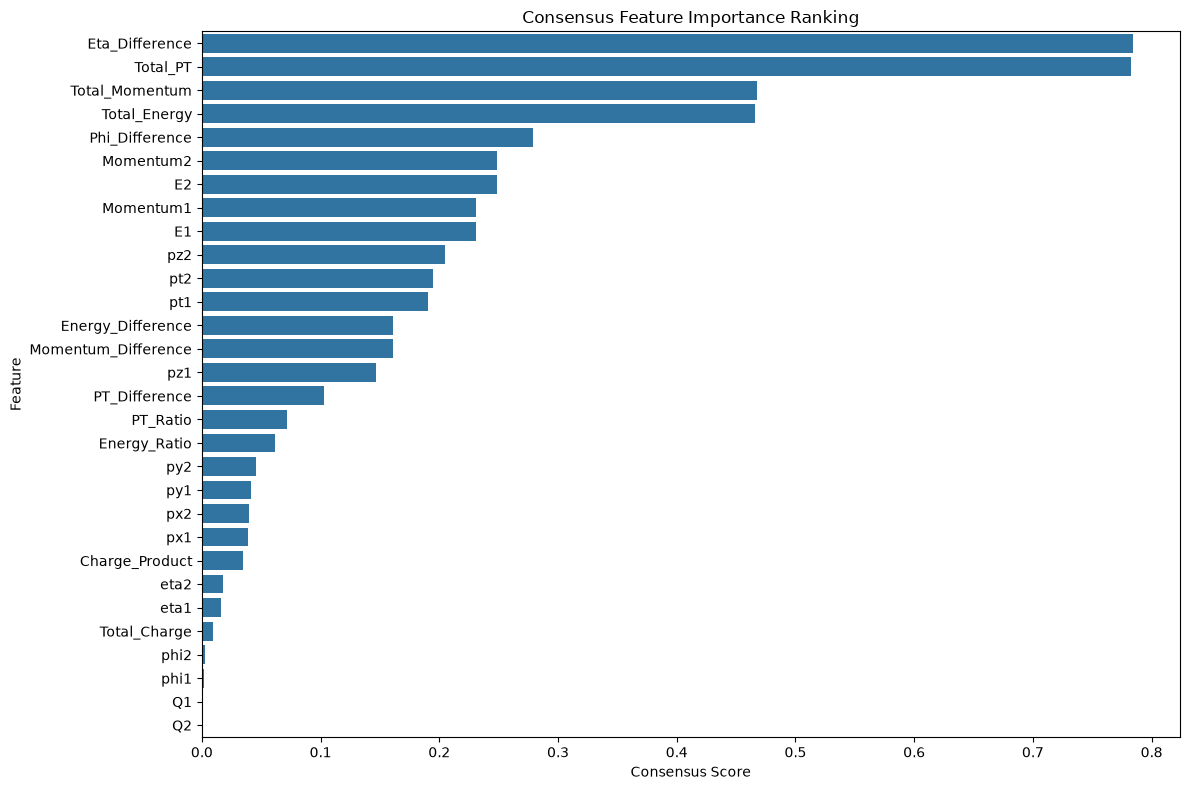

In [40]:
# Consensus Feature Importance
# Visualize the overall importance of each feature
# using the Consensus Score, which combines
# multiple feature ranking techniques.
# Higher Consensus Score
# More consistently important feature across
# all feature selection methods.

# Convert the feature names stored in the index
# into a regular DataFrame column
feature_rankings_plot = feature_rankings.reset_index()

# Rename the index column to 'Feature'
# for better readability in the plot
feature_rankings_plot = feature_rankings_plot.rename(
    columns={"index": "Feature"}
)

# Create the figure
plt.figure(figsize=(12, 8))

# Plot Consensus Score for each feature
sns.barplot(
    data=feature_rankings_plot,
    x="Consensus Score",
    y="Feature"
)

# Add plot title and axis labels
plt.title("Consensus Feature Importance Ranking")
plt.xlabel("Consensus Score")
plt.ylabel("Feature")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

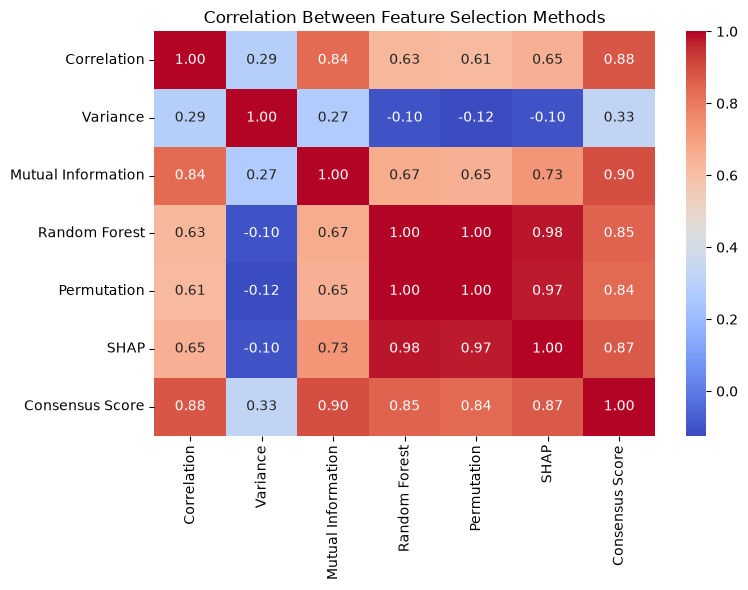

In [41]:
# Correlation Between Feature Selection Methods
# Measure the agreement between different feature
# selection techniques.
# High correlation indicates that two methods
# rank features similarly.

plt.figure(figsize=(8,6))

sns.heatmap(
    normalized_scores.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Feature Selection Methods")

plt.tight_layout()

plt.show()

In [42]:
# Save Feature Rankings
# These rankings will be used in:
# Notebook 6 : Model Training
# Notebook 8 : Sensor Purging

import os

os.makedirs("../outputs", exist_ok=True)

feature_rankings.to_csv(
    "../outputs/feature_rankings.csv"
)

print("Feature Rankings Saved Successfully")

Feature Rankings Saved Successfully


In [43]:
# Save Individual Feature Scores

normalized_scores.to_csv(
    "../outputs/feature_scores.csv"
)

print("Feature Scores Saved Successfully")

Feature Scores Saved Successfully


In [44]:
# Feature Selection Summary

print("="*70)

print("""
Notebook 5 Completed Successfully

Feature Selection Techniques Used

✓ Correlation Analysis

✓ Variance Analysis

✓ Mutual Information

✓ Random Forest Feature Importance

✓ Permutation Importance

✓ SHAP Explainability

✓ Min-Max Score Normalization

✓ Consensus Feature Ranking

Outputs Generated

✓ feature_rankings.csv

✓ feature_scores.csv

Next Notebook

Model Training & Evaluation
""")

print("="*70)


Notebook 5 Completed Successfully

Feature Selection Techniques Used

✓ Correlation Analysis

✓ Variance Analysis

✓ Mutual Information

✓ Random Forest Feature Importance

✓ Permutation Importance

✓ SHAP Explainability

✓ Min-Max Score Normalization

✓ Consensus Feature Ranking

Outputs Generated

✓ feature_rankings.csv

✓ feature_scores.csv

Next Notebook

Model Training & Evaluation

